# Exploratory Data Analysis (EDA) - Hotel Booking Demand

## Syfte

Syftet med denna EDA är att undersöka datasetets innehåll, kvalitet och begränsningar inför modellering av hotellavbokningar.

Analysen fokuserar på att:
- undersöka datasetets struktur och målvariabel
- identifiera saknade värden, dubbletter och avvikande värden
- identifiera variabler med risk för dataläckage eller annan osäkerhet
- undersöka relevanta samband med avbokningar
- skapa underlag för preprocessing och feature-urval

In [3]:
# Aktivera autoreload så att ändringar i src/ slår igenom utan att starta om kerneln
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Säkerställ att projektroten ligger i sys.path för rena imports
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Grundläggande plottinginställningar
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
from src.data_loader import load_raw_data

# Läser in rådatan (hämtas via kagglehub-cachen)
df = load_raw_data()

2026-10-09 14:25:53 [INFO] src.data_loader: Kontrollerar/hämtar dataset via kagglehub...
2026-10-09 14:25:54 [INFO] src.data_loader: Läser in rådata från: C:\Users\malin\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1\hotel_bookings.csv
2026-10-09 14:25:54 [INFO] src.data_loader: Data inläst framgångsrikt. Dimensioner: (119390, 32)


### Hjälpfunktion för avbokningsanalys

För att undvika upprepad kod används funktionen `cancellation_summary()` i flera av analyserna nedan.

Funktionen grupperar bokningarna efter en vald variabel och beräknar antal och andel bokningar samt antal och andel avbokningar för varje grupp. Det gör resultaten enklare att jämföra mellan olika variabler.

In [5]:
def cancellation_summary(data: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """
    Sammanfattar antal bokningar och avbokningar grupperat på en variabel.

    Args:
        data: DataFrame som innehåller bokningsdata.
        group_col: Namnet på kolumnen som data ska grupperas efter.

    Returns:
        En DataFrame med antal och andel bokningar samt antal och andel avbokningar.
    """
    summary = (
        data.groupby(group_col, observed=True)["is_canceled"]
        .agg(
            bookings="count",
            cancellations="sum",
            cancellation_rate="mean"
        )
    )

    summary["booking_percent"] = summary["bookings"] / len(data) * 100
    summary["cancellation_rate"] *= 100

    return summary[
        ["bookings", "booking_percent", "cancellations", "cancellation_rate"]
    ].round(2)

In [6]:
print(f"Antal bokningar: {df.shape[0]:,}")
print(f"Antal variabler: {df.shape[1]}")

df.head().T

Antal bokningar: 119,390
Antal variabler: 32


,0,1,2,3,4
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel
is_canceled,0,0,0,0,0
lead_time,342,737,7,13,14
arrival_date_year,2015,2015,2015,2015,2015
arrival_date_month,July,July,July,July,July
arrival_date_week_number,27,27,27,27,27
arrival_date_day_of_month,1,1,1,1,1
stays_in_weekend_nights,0,0,0,0,0
stays_in_week_nights,0,0,1,1,2
adults,2,2,1,1,2


### Variabler och datatyper

För att förstå datasetets struktur undersöks variablernas datatyper och antal unika värden. Antalet unika värden hjälper även till att identifiera variabler som kan vara kategoriska trots att de är numeriskt kodade.

In [7]:
column_info = pd.DataFrame({
    "datatype": df.dtypes,
    "unique_values": df.nunique()
})

column_info

,datatype,unique_values
hotel,str,2
is_canceled,int64,2
lead_time,int64,479
arrival_date_year,int64,3
arrival_date_month,str,12
arrival_date_week_number,int64,53
arrival_date_day_of_month,int64,31
stays_in_weekend_nights,int64,17
stays_in_week_nights,int64,35
adults,int64,14


## 3. Målvariabel – avbokningar

Målvariabeln `is_canceled` anger om en bokning avbokades (`1`) eller inte (`0`).

Vi undersöker fördelningen för att förstå hur vanligt det är med avbokningar och om målvariabeln är obalanserad.

In [8]:
target_counts = df["is_canceled"].value_counts().sort_index()

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percent": target_counts / len(df) * 100
})

target_distribution.index = ["Not canceled", "Canceled"]
target_distribution.round(2)

,count,percent
Not canceled,75166,62.96
Canceled,44224,37.04


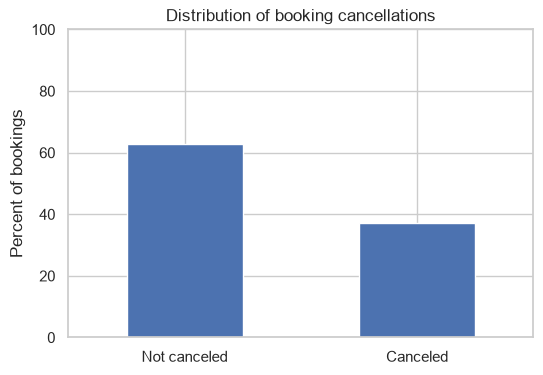

In [9]:
ax = target_distribution["percent"].plot(
    kind="bar",
    figsize=(6, 4)
)

ax.set_title("Distribution of booking cancellations")
ax.set_xlabel("")
ax.set_ylabel("Percent of bookings")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)

plt.show()

### Observation

37,04 % av bokningarna i datasetet avbokades. Målvariabeln är något obalanserad, men båda klasserna är väl representerade.

Det innebär att accuracy inte bör användas som enda utvärderingsmått. En modell som alltid förutspår att en bokning inte kommer att avbokas skulle exempelvis få cirka 63 % accuracy utan att identifiera en enda faktisk avbokning.

### Avbokningar per hotell

Datasetet innehåller bokningar från två olika hotell. Vi jämför avbokningsandelen mellan hotellen för att undersöka om målvariabeln skiljer sig mellan dem.

In [10]:
cancellation_by_hotel = cancellation_summary(df, "hotel")

cancellation_by_hotel

,bookings,booking_percent,cancellations,cancellation_rate
hotel,,,,
City Hotel,79330,66.45,33102,41.73
Resort Hotel,40060,33.55,11122,27.76


### Observation

Avbokningsandelen skiljer sig mellan hotellen: 41,73 % för City Hotel och 27,76 % för Resort Hotel. `hotel` kan därför vara relevant att undersöka vidare som feature.

Skillnaden visar ett samband, men innebär inte att hotelltypen orsakar avbokningar.

## 4. Datakvalitet

Innan datan används för modellering undersöks möjliga kvalitetsproblem som saknade värden, dubbletter och avvikande värden.

Syftet är att identifiera problem och osäkerheter som behöver hanteras eller undersökas vidare inför preprocessing.

### Saknade värden

Vi undersöker vilka variabler som innehåller saknade värden och hur stor andel av observationerna som påverkas.

In [11]:
missing_values = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_values = (
    missing_values[missing_values["missing_count"] > 0]
    .sort_values("missing_percent", ascending=False)
)

missing_values.round(2)

,missing_count,missing_percent
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


### Observation

Saknade värden förekommer främst i `company` (94,31 %) och `agent` (13,69 %). `country` och `children` saknas endast i en liten andel av observationerna.

För `company` och `agent` kan avsaknad av värde representera att bokningen inte är kopplad till ett företag eller en agent. De saknade värdena bör därför inte automatiskt behandlas som felaktig data. Hur de ska hanteras beslutas inför preprocessing.

### Dubbletter

Vi undersöker om datasetet innehåller helt identiska rader. Ett stort antal dubbletter kan påverka modelleringen, men identiska rader behöver inte automatiskt innebära felaktig data eftersom flera bokningar kan ha samma egenskaper.

In [12]:
duplicate_count = df.duplicated().sum()
duplicate_percent = df.duplicated().mean() * 100

print(f"Antal dubbletter: {duplicate_count:,}")
print(f"Andel dubbletter: {duplicate_percent:.2f} %")

Antal dubbletter: 31,994
Andel dubbletter: 26.80 %


#### Dubbletter per hotell

Eftersom en stor andel av datasetet består av identiska rader undersöks om dubbletterna är jämnt fördelade mellan de två hotellen.

In [13]:
duplicates_by_hotel = (
    df.assign(is_duplicate=df.duplicated())
    .groupby("hotel")["is_duplicate"]
    .agg(
        bookings="count",
        duplicates="sum",
        duplicate_rate="mean"
    )
)

duplicates_by_hotel["duplicate_rate"] *= 100

duplicates_by_hotel.round(2)

,bookings,duplicates,duplicate_rate
hotel,,,
City Hotel,79330,25902,32.65
Resort Hotel,40060,6092,15.21


### Observation

Datasetet innehåller 31 994 helt identiska rader, vilket motsvarar 26,80 % av observationerna. Andelen skiljer sig mellan hotellen: 32,65 % för City Hotel och 15,21 % för Resort Hotel.

Eftersom datasetet saknar ett unikt boknings-ID går det inte att avgöra om dessa rader är felaktiga dubbletter eller separata bokningar med samma registrerade egenskaper. Att ta bort dem skulle dessutom påverka de två hotellen olika. Hur dubbletterna ska hanteras behöver därför beslutas och motiveras inför preprocessing.

### Avvikande och orimliga värden

Vi undersöker några variabler där extrema eller orimliga värden kan tyda på datakvalitetsproblem och påverka den fortsatta analysen.

Först kontrolleras om det finns bokningar där det registrerade antalet gäster är noll.

In [14]:
zero_guests = df[
    (df["adults"] == 0) &
    (df["children"].fillna(0) == 0) &
    (df["babies"] == 0)
]

print(f"Bokningar med 0 registrerade gäster: {len(zero_guests):,}")
print(f"Andel av datasetet: {len(zero_guests) / len(df) * 100:.2f} %")

Bokningar med 0 registrerade gäster: 180
Andel av datasetet: 0.15 %


Därefter undersöks fördelningen för `adr` (Average Daily Rate) för att identifiera eventuella extrema eller orimliga värden.

In [15]:
df["adr"].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

För att förstå extremvärdena bättre undersöks bokningarna med negativa och mycket höga `adr`-värden närmare.

In [16]:
df.loc[
    (df["adr"] < 0) | (df["adr"] > 1000),
    ["hotel", "adr", "is_canceled"]
].sort_values("adr")

,hotel,adr,is_canceled
14969,Resort Hotel,-6.38,0
48515,City Hotel,5400.00,1


### Observation

Det finns 180 bokningar (0,15 %) där inga gäster är registrerade.

`adr` innehåller två tydliga extremvärden: -6,38 och 5400. Det negativa värdet framstår som orimligt och 5400 är extremt i förhållande till resten av fördelningen.

Beslut om hur dessa observationer ska hanteras behöver tas inför preprocessing.

## 5. Dataläckage och osäkra variabler

Modellen är tänkt att förutsäga risken för avbokning utifrån information som är tillgänglig vid bokningstillfället. Därför behöver variabler som kan innehålla information från senare delar av bokningsprocessen identifieras.

Om sådan information används vid träningen kan dataläckage uppstå, vilket innebär att modellen får tillgång till information som inte skulle vara känd när en verklig prediktion görs.

### Reservation status

`reservation_status` beskriver bokningens slutliga status. Eftersom denna information kan vara känd först efter att bokningen har avbokats eller genomförts finns en tydlig risk för dataläckage.

Vi jämför därför `reservation_status` med målvariabeln `is_canceled`.

In [17]:
pd.crosstab(
    df["reservation_status"],
    df["is_canceled"],
    margins=True
)

is_canceled,0,1,All
reservation_status,,,
Canceled,0,43017,43017
Check-Out,75166,0,75166
No-Show,0,1207,1207
All,75166,44224,119390


### Observation

`reservation_status` avslöjar målvariabeln: `Canceled` och `No-Show` motsvarar `is_canceled = 1`, medan `Check-Out` motsvarar `is_canceled = 0`.

Variabeln innehåller information om utfallet och ska därför inte användas som feature.

### Reservation status date

`reservation_status_date` anger datumet då bokningens slutliga status registrerades. Informationen är därför inte tillgänglig vid bokningstillfället och ska inte användas som feature i modellen.

### Reserved och assigned room type

`reserved_room_type` beskriver den rumstyp som bokades, medan `assigned_room_type` beskriver den rumstyp som senare tilldelades bokningen.

Eftersom den tilldelade rumstypen kan bestämmas eller ändras efter bokningstillfället undersöks hur ofta den skiljer sig från den ursprungligen bokade rumstypen.

In [18]:
room_type_changed = (
    df["reserved_room_type"] != df["assigned_room_type"]
)

print(f"Olika rumstyper: {room_type_changed.sum():,}")
print(f"Andel: {room_type_changed.mean() * 100:.2f} %")

Olika rumstyper: 14,917
Andel: 12.49 %


### Observation

I 14 917 bokningar (12,49 %) skiljer sig `assigned_room_type` från den ursprungligen bokade rumstypen.

Eftersom `assigned_room_type` kan bestämmas eller ändras efter bokningstillfället ska den inte användas som feature. `reserved_room_type` är däremot tillgänglig vid bokningen och kan undersökas vidare.

### Booking changes

`booking_changes` anger hur många ändringar som har gjorts i bokningen. Eftersom ändringar kan ha skett efter att bokningen skapades är det osäkert om informationen är tillgänglig vid det tänkta prediktionstillfället.

Vi undersöker om avbokningsandelen skiljer sig mellan bokningar som har registrerade ändringar och bokningar som inte har det.

In [19]:
booking_changes_data = df.assign(
    has_booking_changes=df["booking_changes"] > 0
)

booking_changes_summary = cancellation_summary(
    booking_changes_data,
    "has_booking_changes"
)

booking_changes_summary

,bookings,booking_percent,cancellations,cancellation_rate
has_booking_changes,,,,
False,101314,84.86,41391,40.85
True,18076,15.14,2833,15.67


### Observation

Avbokningsandelen är 40,85 % för bokningar utan registrerade ändringar och 15,67 % för bokningar med minst en ändring.

Detta innebär inte att ändringar minskar risken för avbokning. Eftersom datasetet inte visar när ändringarna gjordes kan informationen ha uppstått efter bokningstillfället.

`booking_changes` ska därför inte användas som feature när prediktionen görs vid bokningstillfället. Själva bokningarna behålls eftersom osäkerheten gäller variabeln, inte observationerna.

### Country

`country` anger gästens ursprungsland. Det är osäkert om denna information alltid var tillgänglig redan när bokningen skapades eller om den i vissa fall registrerades senare.

Vi undersöker först hur bokningarna är fördelade mellan de vanligaste länderna.

In [20]:
country_distribution = (
    df["country"]
    .value_counts()
    .head(10)
    .to_frame("bookings")
)

country_distribution["percent"] = (
    country_distribution["bookings"] / len(df) * 100
)

country_distribution.round(2)

,bookings,percent
country,,
PRT,48590,40.70
GBR,12129,10.16
FRA,10415,8.72
ESP,8568,7.18
DEU,7287,6.10
ITA,3766,3.15
IRL,3375,2.83
BEL,2342,1.96
BRA,2224,1.86


### Portugal jämfört med övriga länder

Portugal (`PRT`) är det klart vanligaste landet i datasetet och står för 40,70 % av bokningarna. Eftersom en så stor del av datan tillhör samma land undersöks om avbokningsandelen skiljer sig mellan bokningar från Portugal och övriga länder.

In [21]:
country_data = (
    df[df["country"].notna()]
    .assign(
        country_group=lambda x: x["country"].eq("PRT").map({
            True: "Portugal",
            False: "Other countries"
        })
    )
)

country_cancellation = cancellation_summary(
    country_data,
    "country_group"
)

country_cancellation

,bookings,booking_percent,cancellations,cancellation_rate
country_group,,,,
Other countries,70312,59.13,16638,23.66
Portugal,48590,40.87,27519,56.64


### Observation

Avbokningsandelen är 56,64 % för bokningar från Portugal, jämfört med 23,66 % för övriga länder.

`country` visar alltså ett tydligt samband med målvariabeln, men eftersom det är osäkert om informationen alltid var tillgänglig vid bokningstillfället finns risk för dataläckage. Variabeln bör därför inte användas utan ytterligare information om när den registrerades.

### Deposit type

`deposit_type` beskriver vilken typ av deposition som är kopplad till bokningen.

Vi undersöker först hur bokningarna är fördelade mellan de olika depositionstyperna och om avbokningsandelen skiljer sig mellan grupperna.

In [22]:
deposit_summary = cancellation_summary(df, "deposit_type")

deposit_summary

,bookings,booking_percent,cancellations,cancellation_rate
deposit_type,,,,
No Deposit,104641,87.65,29694,28.38
Non Refund,14587,12.22,14494,99.36
Refundable,162,0.14,36,22.22


#### Fördjupning av Non Refund-bokningar

`Non Refund` sticker tydligt ut med en avbokningsandel på 99,36 %. Eftersom detta är ett ovanligt starkt samband undersöks gruppen närmare för att se om bokningarna är koncentrerade till vissa agents.

In [23]:
non_refund = df[df["deposit_type"] == "Non Refund"]

non_refund_agents = (
    cancellation_summary(non_refund, "agent")
    .sort_values("bookings", ascending=False)
    .head(10)
)

non_refund_agents

,bookings,booking_percent,cancellations,cancellation_rate
agent,,,,
1.0,4072,27.92,4072,100.0
19.0,719,4.93,719,100.0
6.0,642,4.40,642,100.0
37.0,627,4.30,627,100.0
3.0,623,4.27,623,100.0
29.0,500,3.43,500,100.0
21.0,375,2.57,375,100.0
229.0,340,2.33,340,100.0
20.0,256,1.75,256,100.0


#### Non Refund och dubbletter

Eftersom `Non Refund` har en mycket hög avbokningsandel och är koncentrerad till vissa agents undersöks om gruppen även innehåller en hög andel identiska rader.

In [24]:
duplicate_by_deposit = (
    df.assign(is_duplicate=df.duplicated())
    .groupby("deposit_type")["is_duplicate"]
    .agg(
        bookings="count",
        duplicates="sum",
        duplicate_rate="mean"
    )
)

duplicate_by_deposit["duplicate_rate"] *= 100

duplicate_by_deposit.round(2)

,bookings,duplicates,duplicate_rate
deposit_type,,,
No Deposit,104641,18390,17.57
Non Refund,14587,13549,92.88
Refundable,162,55,33.95


### Observation

`Non Refund` skiljer sig tydligt från övriga depositionstyper. Av 14 587 bokningar avbokades 99,36 %. Samtliga av de tio vanligaste agenterna har 100 % avbokningar för sina `Non Refund`-bokningar, och 92,88 % av raderna är identiska med en tidigare rad. Gruppen står därmed för 13 549 av datasetets 31 994 identiska rader, cirka 42 %.

Eftersom datasetet saknar ett unikt boknings-ID går det inte att avgöra om de identiska raderna är felaktiga dubbletter eller separata bokningar med samma registrerade egenskaper. För att se om mönstret beror på agenterna eller på depositionstypen jämförs nedan samma agenters övriga bokningar.

### Non Refund och agenternas övriga bokningar

In [25]:
top_agents = non_refund["agent"].value_counts().head(10).index

other_top_agents = df[(df["deposit_type"] != "Non Refund") & (df["agent"].isin(top_agents))]

(
    cancellation_summary(other_top_agents, "agent")
    .sort_values("bookings", ascending=False)
)

,bookings,booking_percent,cancellations,cancellation_rate
agent,,,,
1.0,3119,34.97,1208,38.73
6.0,2648,29.69,383,14.46
3.0,713,7.99,148,20.76
37.0,603,6.76,90,14.93
21.0,500,5.61,131,26.20
229.0,446,5.00,144,32.29
19.0,342,3.83,61,17.84
20.0,284,3.18,103,36.27
29.0,183,2.05,46,25.14


### Observation

Samma agenter har en avbokningsandel på 14–51 % för sina övriga bokningar, i nivå med eller något över genomsnittet.  
Det extrema mönstret beror alltså på depositionstypen och inte på agenterna.

Enligt Antonio m.fl. (2019) beräknades `deposit_type` utifrån de betalningar som registrerats före ankomst- eller avbokningsdatumet. "Non Refund" betyder att betalningarna motsvarade minst hela vistelsens kostnad, alltså att bokningen var helt förbetald. Värdet bygger därmed på betalningar fram till ankomsten eller avbokningen, och det är inte säkert att det var känt vid bokningstillfället.

`Non Refund`-bokningarna tas inte bort, eftersom de är en del av hotellens bokningar. Mönstret tyder dock på att gruppen inte består av vanliga enskilda bokningar, och variabeln är beräknad utifrån betalningar fram till ankomst eller avbokning. Modellen körs därför både med och utan `deposit_type`, och resultaten redovisas både för alla bokningar och för bokningar utan `Non Refund`.

## 6. Samband med avbokningar

Efter granskningen av datakvalitet och möjliga risker för dataläckage undersöks ett urval av variabler som kan vara relevanta för att förutsäga avbokningar.

Fokus ligger på variabler som är rimliga att känna till vid bokningstillfället och som kan bidra med information till modelleringen.

### Lead time

`lead_time` anger antalet dagar mellan bokningstillfället och ankomstdatumet.

Eftersom tiden mellan bokning och ankomst kan påverka sannolikheten att en bokning hinner avbokas undersöks först variabelns fördelning.

In [26]:
df["lead_time"].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

För att undersöka sambandet mellan `lead_time` och avbokningar delas bokningarna in i intervall utifrån hur långt före ankomst de gjordes. Därefter jämförs avbokningsandelen mellan grupperna.

In [27]:
lead_time_groups = pd.cut(
    df["lead_time"],
    bins=[-1, 30, 60, 90, 180, 365, float("inf")],
    labels=["0–30", "31–60", "61–90", "91–180", "181–365", "366+"]
)

lead_time_data = df.assign(
    lead_time_group=lead_time_groups
)

lead_time_summary = cancellation_summary(
    lead_time_data,
    "lead_time_group"
)

lead_time_summary

,bookings,booking_percent,cancellations,cancellation_rate
lead_time_group,,,,
0–30,38706,32.42,7185,18.56
31–60,16970,14.21,6174,36.38
61–90,12583,10.54,4967,39.47
91–180,26439,22.15,11821,44.71
181–365,21544,18.05,11947,55.45
366+,3148,2.64,2130,67.66


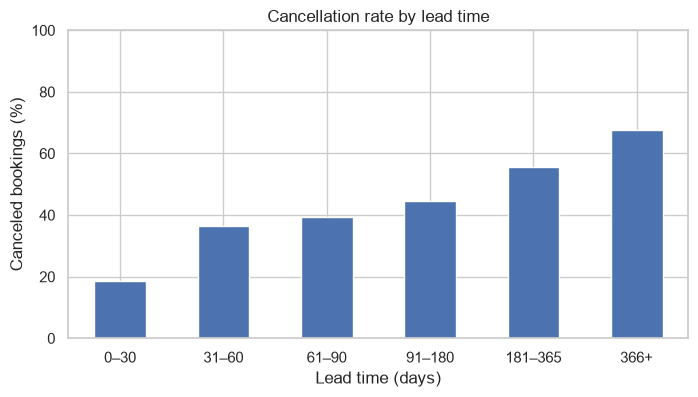

In [28]:
ax = lead_time_summary["cancellation_rate"].plot(
    kind="bar",
    figsize=(8, 4)
)

ax.set_title("Cancellation rate by lead time")
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("Canceled bookings (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)

plt.show()

### Observation

Avbokningsandelen ökar tydligt med längre `lead_time`. För bokningar som gjordes 0–30 dagar före ankomst avbokades 18,56 %, jämfört med 67,66 % för bokningar som gjordes mer än ett år i förväg.

`lead_time` visar därmed ett tydligt samband med målvariabeln och är relevant både som möjlig feature och för en enkel regelbaserad baseline.

Ökningen sker successivt utan någon tydlig naturlig brytpunkt i de undersökta intervallen. En eventuell gräns för baselinen behöver därför väljas och motiveras separat.

### Market segment

`market_segment` beskriver vilket marknadssegment bokningen tillhör.

Vi undersöker först hur bokningarna är fördelade mellan de olika segmenten och därefter om avbokningsandelen skiljer sig mellan grupperna.

In [29]:
market_segment_summary = (
    cancellation_summary(df, "market_segment")
    .sort_values("bookings", ascending=False)
)

market_segment_summary

,bookings,booking_percent,cancellations,cancellation_rate
market_segment,,,,
Online TA,56477,47.30,20739,36.72
Offline TA/TO,24219,20.29,8311,34.32
Groups,19811,16.59,12097,61.06
Direct,12606,10.56,1934,15.34
Corporate,5295,4.44,992,18.73
Complementary,743,0.62,97,13.06
Aviation,237,0.20,52,21.94
Undefined,2,0.00,2,100.00


### Observation

Avbokningsandelen skiljer sig mellan marknadssegmenten. `Groups` har högst avbokningsandel bland de större segmenten (61,06 %), medan `Direct` har betydligt lägre (15,34 %). `Online TA` och `Offline TA/TO`, som står för en stor del av bokningarna, har avbokningsandelar på 36,72 % respektive 34,32 %.

`Undefined` har 100 % avbokningar men innehåller endast två bokningar, vilket är för få för att dra generella slutsatser.

`market_segment` visar därmed ett tydligt samband med målvariabeln och är relevant som möjlig feature.

### Distribution channel

`distribution_channel` beskriver vilken kanal bokningen gjordes via. "TA" står för resebyråer (Travel Agents) och "TO" för researrangörer (Tour Operators).

Vi undersöker först hur bokningarna är fördelade mellan kanalerna och därefter om avbokningsandelen skiljer sig mellan grupperna.

In [40]:
distribution_channel_summary = (
    cancellation_summary(df, "distribution_channel")
    .sort_values("bookings", ascending=False)
)

distribution_channel_summary

,bookings,booking_percent,cancellations,cancellation_rate
distribution_channel,,,,
TA/TO,97870,81.98,40152,41.03
Direct,14645,12.27,2557,17.46
Corporate,6677,5.59,1474,22.08
GDS,193,0.16,37,19.17
Undefined,5,0.00,4,80.00


### Observation

Avbokningsandelen skiljer sig mellan distributionskanalerna. `TA/TO`, alltså bokningar via resebyråer och researrangörer, står för den största delen av bokningarna (cirka 82 %) och har högst avbokningsandel bland de större kanalerna (41,03 %). `Direct` har betydligt lägre avbokningsandel (17,46 %), och `Corporate` ligger på 22,08 %.

`Undefined` har 80 % avbokningar men innehåller endast fem bokningar, vilket är för få för att dra generella slutsatser.

`distribution_channel` visar därmed ett tydligt samband med målvariabeln och är relevant som möjlig feature. Kanalen överlappar dock delvis med `market_segment`, eftersom båda beskriver om bokningen gjorts via resebyrå, direkt eller via företag.

### Customer type

`customer_type` beskriver vilken typ av kund eller bokning som reservationen tillhör.

Vi undersöker hur bokningarna är fördelade mellan de olika kundtyperna och om avbokningsandelen skiljer sig mellan grupperna.

In [30]:
customer_type_summary = (
    cancellation_summary(df, "customer_type")
    .sort_values("bookings", ascending=False)
)

customer_type_summary

,bookings,booking_percent,cancellations,cancellation_rate
customer_type,,,,
Transient,89613,75.06,36514,40.75
Transient-Party,25124,21.04,6389,25.43
Contract,4076,3.41,1262,30.96
Group,577,0.48,59,10.23


### Observation

Avbokningsandelen skiljer sig mellan kundtyperna. `Transient` står för 75,06 % av bokningarna och har en avbokningsandel på 40,75 %. `Transient-Party` och `Contract` har lägre avbokningsandelar på 25,43 % respektive 30,96 %.

`Group` har lägst avbokningsandel (10,23 %), men innehåller endast 577 bokningar och bör därför tolkas med viss försiktighet.

`customer_type` visar därmed ett samband med målvariabeln och kan vara relevant som feature.

### Tidigare bokningshistorik

Information om gästens tidigare bokningar kan vara relevant för risken för avbokning. Vi undersöker därför `is_repeated_guest`, som anger om gästen har bokat tidigare, samt `previous_cancellations`, som anger antalet tidigare avbokningar.

Först jämförs avbokningsandelen mellan nya och återkommande gäster.

In [31]:
repeated_guest_summary = cancellation_summary(df, "is_repeated_guest")

repeated_guest_summary.index = ["New guest", "Repeated guest"]

repeated_guest_summary

,bookings,booking_percent,cancellations,cancellation_rate
New guest,115580,96.81,43672,37.79
Repeated guest,3810,3.19,552,14.49


In [32]:
previous_cancellations_summary = cancellation_summary(
    df, "previous_cancellations"
)

previous_cancellations_summary

,bookings,booking_percent,cancellations,cancellation_rate
previous_cancellations,,,,
0,112906,94.57,38282,33.91
1,6051,5.07,5714,94.43
2,116,0.10,38,32.76
3,65,0.05,20,30.77
4,31,0.03,7,22.58
5,19,0.02,2,10.53
6,22,0.02,7,31.82
11,35,0.03,10,28.57
13,12,0.01,11,91.67


### Observation

Återkommande gäster har en lägre avbokningsandel (14,49 %) än nya gäster (37,79 %), men utgör endast 3,19 % av bokningarna.

För bokningar med exakt en tidigare avbokning är avbokningsandelen 94,43 %, jämfört med 33,91 % för bokningar utan tidigare avbokningar. Grupperna med fler än en tidigare avbokning är betydligt mindre och avbokningsandelen varierar kraftigt. Det går därför inte att dra slutsatsen att risken generellt ökar med antalet tidigare avbokningar.

Både `is_repeated_guest` och `previous_cancellations` visar samband med målvariabeln och kan vara relevanta features eftersom de beskriver tidigare bokningshistorik.

### Reserved room type

`reserved_room_type` beskriver den rumstyp som gästen ursprungligen bokade och är information som finns tillgänglig vid bokningstillfället.

Vi undersöker hur bokningarna är fördelade mellan rumstyperna och om avbokningsandelen skiljer sig mellan dem.

In [33]:
room_type_summary = (
    cancellation_summary(df, "reserved_room_type")
    .sort_values("bookings", ascending=False)
)

room_type_summary

,bookings,booking_percent,cancellations,cancellation_rate
reserved_room_type,,,,
A,85994,72.03,33630,39.11
D,19201,16.08,6102,31.78
E,6535,5.47,1914,29.29
F,2897,2.43,880,30.38
G,2094,1.75,763,36.44
B,1118,0.94,368,32.92
C,932,0.78,308,33.05
H,601,0.50,245,40.77
P,12,0.01,12,100.00


### Observation

`reserved_room_type` domineras av rumstyp A, som står för 72,03 % av bokningarna. Bland de större rumstyperna varierar avbokningsandelen mellan cirka 29 % och 39 %.

Rumstyp P har 100 % avbokningar men innehåller endast 12 bokningar, vilket är för få för att dra generella slutsatser.

Sambandet med avbokningar är mindre tydligt än för flera tidigare undersökta variabler. Eftersom `reserved_room_type` är känd vid bokningstillfället kan den ändå vara relevant som feature. Hur mycket den bidrar får utvärderas vid modelleringen.

### Korrelation mellan utvalda variabler

För att komplettera analyserna ovan undersöks linjära samband mellan ett urval av numeriska och binära variabler, inklusive målvariabeln `is_canceled`.

Vi inkluderar variabler som kan vara relevanta vid bokningstillfället. Numeriskt kodade kategorier och ID-variabler, exempelvis `agent` och `company`, exkluderas eftersom deras värden inte representerar en faktisk storleksordning.

In [34]:
numeric_features = [
    "is_canceled",
    "lead_time",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled"
]

correlation_matrix = df[numeric_features].corr()

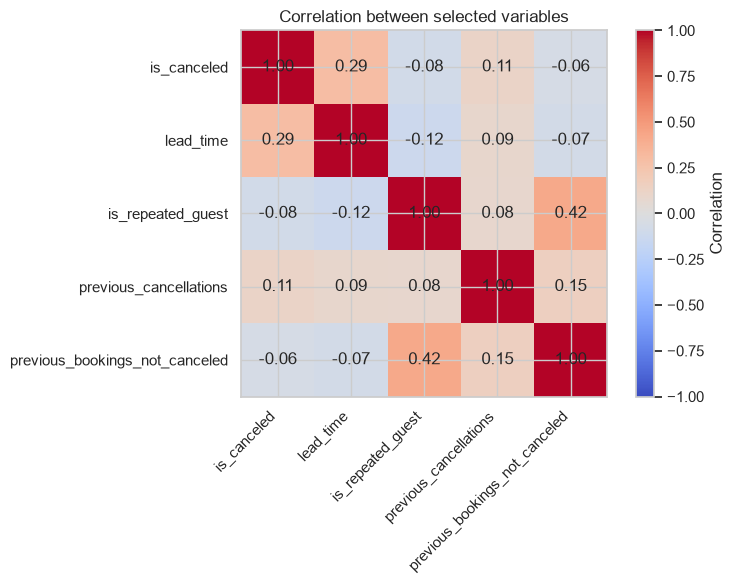

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.columns)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation between selected variables")
fig.colorbar(image, ax=ax, label="Correlation")

plt.tight_layout()
plt.show()

### Observation

`lead_time` har det tydligaste linjära sambandet med `is_canceled` bland de undersökta variablerna, med en korrelation på 0,29. Övriga variabler visar svagare linjära samband med målvariabeln.

Korrelationen används som ett komplement till tidigare analyser, inte för att automatiskt välja bort features. Ett svagt linjärt samband innebär inte att en variabel saknar prediktiv information, eftersom samband även kan vara icke-linjära eller bero på kombinationer av flera variabler.

## 7. Tid och bokningsdatum

### Skapa tidsvariabler

I datasetet finns inte bokningsdatum men det kan skapas utifrån dessa variabler:

`arrival_date_day_of_month` -> Day of the month of the arrival date  
`arrival_date_month` -> Month of arrival date with 12 categories: “January” to “December”  
`arrival_date_year` -> Year of arrival date  
`lead_time` -> Number of days that elapsed between the entering date of the booking into the PMS and the arrival date  

Vi skapar också `outcome_date` från `reservation_status_date`, som anger när bokningens status senast ändrades:

- avbokningsdatum för avbokade bokningar
- utcheckningsdatum för genomförda
- ankomstdatum för no-shows  

`outcome_date` används bara i EDA:n och aldrig i modellen, eftersom den avslöjar utfallet.

In [36]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-"
    + df["arrival_date_month"].astype(str) + "-"
    + df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
)
df["booking_date"] = df["arrival_date"] - pd.to_timedelta(df["lead_time"], unit="D")
df["outcome_date"] = pd.to_datetime(df["reservation_status_date"])

# Rimlighetskontroller
canc = df[df["is_canceled"] == 1]
print("Utfall före bokningen:", (df["outcome_date"] < df["booking_date"]).sum())
print("Avbokningar efter ankomsten:", (canc["outcome_date"] > canc["arrival_date"]).sum())

Utfall före bokningen: 0
Avbokningar efter ankomsten: 0


### Observation

Inget utfall ligger före bokningsdatumet, och ingen bokning är avbokad efter ankomstdatumet.  
Det sista betyder att om en bokning avbokas eller blir en no-show är känt senast vid ankomsten.

### Vilka bokningar får modellen lära sig av?

Modellen gör sin prognos vid en viss tidpunkt T och får då bara lära sig av bokningar vars utfall var känt före T.  
Eftersom utfallet är känt senast vid ankomsten tränas modellen på bokningar med ankomst före T.

Avbokningsdatumet används inte, trots att det ofta är känt tidigare, eftersom avbokade bokningar då skulle komma med i träningsdata före genomförda och andelen avbokade skulle bli för hög.

### Tidsperiod och bokningar över tid

Vi vill se datumintervall för bokningar och ankomster

In [37]:
df[["booking_date", "arrival_date"]].agg(["min", "max"])

,booking_date,arrival_date
min,2013-06-24,2015-07-01
max,2017-08-31,2017-08-31


### Observation

Datasetet omfattar ankomster mellan 1 juli 2015 och 31 augusti 2017. Bokningsdatumen börjar tidigare, i juni 2013, eftersom vissa bokningar görs upp till två år före ankomst.  

Vi plottar antal bokningar per bokningsmånad för att se om datan är komplett över hela perioden.

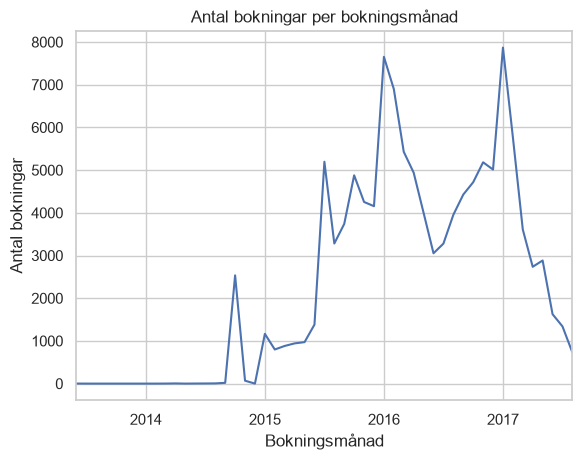

In [38]:
ax = df.set_index("booking_date").resample("MS").size().plot(title="Antal bokningar per bokningsmånad")  # MS = Month Start
ax.set_xlabel("Bokningsmånad")
ax.set_ylabel("Antal bokningar");

### Observation

- **Början:** Före juli 2015 finns bara bokningar med lång ledtid, eftersom ankomsterna börjar då. Antalet är därför lågt fram till sommaren 2015.
- **Slutet:** Bokningar från 2017 finns bara med om ankomsten skedde senast i augusti 2017. Kurvan faller därför brant under 2017.
- **Säsong:** Topparna i januari 2016 och januari 2017 visar att många bokar sommarens resor tidigt på året.
- **Oktober 2014:** En avvikande topp med cirka 2 500 bokningar, som undersöks nedan.

Bokningarna är mest kompletta ungefär från mitten av 2015 till slutet av 2016. Testperioden måste därför ligga så att de flesta bokningar hinner ha sin ankomst innan datan tar slut.

Vi undersöker peak-perioden hösten 2014 mer i detalj.

In [39]:
peak_2014 = df[(df.booking_date >= "2014-09-01") & (df.booking_date < "2014-11-01")]
print(peak_2014["hotel"].value_counts())
print("Andel avbokade:", round(peak_2014["is_canceled"].mean(), 3))
print(peak_2014["deposit_type"].value_counts())
print(peak_2014["agent"].value_counts().head())
print("Andel dubbletter:", round(peak_2014.duplicated().mean(), 3))

hotel
City Hotel      2509
Resort Hotel      44
Name: count, dtype: int64
Andel avbokade: 0.919
deposit_type
Non Refund    1562
No Deposit     991
Name: count, dtype: int64
agent
1.0     2065
6.0      350
5.0       74
21.0      16
40.0       9
Name: count, dtype: int64
Andel dubbletter: 0.918


### Observation

Bokningarna som gjordes i september–oktober 2014 skiljer sig tydligt från resten av datan:

- Nästan alla (2 509 av 2 553) gäller City Hotel.
- 92 % avbokades, jämfört med 37 % i hela datan.
- 61 % är ej återbetalningsbara, jämfört med 12 % i hela datan.
- Cirka 80 % är bokade via samma resebyrå (agent 1).
- 92 % är identiska rader.

Mönstret tyder på att det inte är enskilda gästbokningar utan stora block av rum som en resebyrå reserverade i förväg och sedan avbokade.  

Bokningar gjorda före juli 2015 är ofullständiga, eftersom bara bokningar med lång ledtid finns med, och de innehåller toppen 2014 med ovanligt hög avbokningsandel.

## 8. Sammanfattning och slutsatser från EDA

EDA:n visar att datasetet innehåller flera variabler med tydliga samband med avbokningar, men också datakvalitetsproblem och variabler som behöver hanteras försiktigt inför modelleringen.

### Viktiga observationer

- 37,04 % av bokningarna avbokades. Målvariabeln är något obalanserad, men båda klasserna är väl representerade.
- Avbokningsandelen skiljer sig mellan hotellen, med högre andel för City Hotel (41,7 %) än Resort Hotel (27,8 %).
- Datasetet innehåller 31 994 identiska rader (26,80 %). Eftersom boknings-ID saknas går det inte att avgöra om dessa är felaktiga dubbletter eller separata bokningar med samma registrerade egenskaper.
- Saknade värden förekommer framför allt i `company` och `agent`. Avsaknad av värde kan i dessa variabler representera att bokningen saknar koppling till företag eller agent och behöver därför inte innebära felaktig data.
- `reservation_status` och `reservation_status_date` innehåller information från efter bokningstillfället och ska inte användas som features.
- `assigned_room_type` och `booking_changes` kan innehålla information som uppstått efter bokningen och bör därför inte användas i huvudmodellen.
- `country` visar ett tydligt samband med avbokningar (57 % för Portugal mot 24 % för övriga), men nationaliteten registreras ofta först vid incheckningen (Antonio m.fl., 2019).
- `deposit_type` visar ett extremt mönster för `Non Refund`: 99,36 % avbokas och 92,88 % av raderna är identiska. Samma agenter har 14–51 % avbokningar för sina övriga bokningar, så mönstret beror på depositionstypen. Variabeln är beräknad från betalningar fram till ankomst eller avbokning och var därför inte nödvändigtvis känd vid bokningstillfället. Effekten bör undersökas genom att jämföra modellresultat med och utan variabeln.
- `lead_time`, `market_segment`, `customer_type` och information om tidigare bokningshistorik visar samband med avbokningar och är relevanta att undersöka vidare i modelleringen.
- `reserved_room_type` visar mindre tydliga skillnader men är tillgänglig vid bokningstillfället och kan fortfarande vara relevant som feature.
- Korrelationsanalysen visar att `lead_time` har det tydligaste linjära sambandet med målvariabeln bland de undersökta numeriska variablerna. Svag korrelation används inte som skäl för att automatiskt utesluta andra features.
- Två bokningar i `market_segment` och fem i `distribution_channel` har värdet `Undefined`.
- Bokningsdatum kan härledas som ankomstdatum minus `lead_time`. Datasetet omfattar ankomster juli 2015 – augusti 2017, så bokningar gjorda före juli 2015 och under 2017 är ofullständiga. 
- Bokningar gjorda hösten 2014 bildar en avvikande topp med ett mönster som liknar gruppblock från resebyråer.

Enligt Antonio m.fl. (2019) är det vanligt att gäster ändrar antal personer, vistelsens längd eller rumstyp vid incheckningen eller under vistelsen, och att nationaliteten ofta blir känd först vid incheckningen. Eftersom avbokade bokningar aldrig checkar in skiljer sig fördelningen för `adults`, `children`, `stays_in_weekend_nights`, `stays_in_week_nights`, `meal`, `country` och `assigned_room_type` tydligt mellan avbokade och genomförda bokningar. Dessa variabler bör därför inte användas i modellen. `babies` nämns inte uttryckligen i artikeln, men ingår i antalet personer, som enligt artikeln ofta ändras vid incheckningen. Den bör därför tas bort av samma skäl som `adults` och `children`. Eftersom bebisar förekommer i mycket få bokningar påverkar beslutet modellen lite.

### Inför nästa steg

EDA:n ligger till grund för datarensning, feature-urval och preprocessing. Vi behöver särskilt säkerställa att endast information som är tillgänglig vid bokningstillfället används för att undvika dataläckage.

Bokningsdatum används för att göra en kronologisk uppdelning i tränings-, validerings- och testdata, så att modellen tränas på bokningar vars utfall var känt vid prognostidpunkten och utvärderas på bokningar gjorda efter den.